In [1]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json

# plt.rcParams.update(
#     {
#         "font.family": "serif",
#         "font.serif": "CMU Serif",
#         "text.usetex": True,
#         "text.latex.preamble": r"\usepackage{amsmath}",
#         "font.size": 12,
#         "font.weight": "normal",
#         "figure.titlesize": "medium",
#         "xtick.color": "black",
#         "ytick.color": "black",
#         "axes.labelcolor": "black",
#         "text.color": "black",
#         "savefig.dpi": 300,
#         "figure.dpi": 150,
#         "savefig.bbox": "tight",
#     }
# )

tender_order = [
    "Measles",
    "Mumps",
    "Rubella",
    'MMR',
    "Diphtheria",
    "Tetanus",
    "Pertussis",
    "Hib",
    "Polio",
    "Hepatitis_B",
    "Penta",
    "HPV",
    "PCV",
    "Rotavirus",
]

# Define colors for each group
colors = {
    "M/MR/MMR": "blue",
    "Penta/Hexa/Others": "green",
    "HPV": "red",
    "PCV": "purple",
    "Rota": "orange",
}

color_groups = {
    "M/MR/MMR": ["Measles", "Mumps", "Rubella", 'MMR'],
    "Penta/Hexa/Others": ["Diphtheria", "Tetanus", "Pertussis", "Hib", "Polio", "Hepatitis_B", "Penta"],
    "HPV": ["HPV"],
    "PCV": ["PCV"],
    "Rota": ["Rotavirus"],
}

In [2]:
with open("Deterministic_results_F_Q_I_S_MMR_Penta_as_antigen.json") as json_file:
    F_results = json.load(json_file)

start_DF = pd.read_excel("Starting_point.xlsx", sheet_name="F_start")
start_DF["Value"] = 1
start_DF.rename(columns={"Antigen": "Tender", "Starting": "Start", "Ending": "Finish"}, inplace=True)

# Search results by keyword for F (tender schedules)
grouped_results = {k: v for k, v in F_results.items() if k.startswith("F")}

F_values_df = pd.DataFrame.from_dict(grouped_results, orient="index").reset_index()
F_values_df.columns = ["index", "Value"]
F_values_df[["F", "Tender", "Start", "Finish"]] = F_values_df["index"].str.extract(r"(\w+)\[(\w+),\((\d+), (\d+)\)\]")
F_values_df = F_values_df.astype({"Start": "int32", "Finish": "int32", "Value": "float64"})

# remove ongoing tenders by merging start DF and droping columns
result_df = (
    F_values_df.merge(start_DF, on=["Tender", "Start"], how="left", indicator=True)
    .query('_merge == "left_only"')
    .drop("_merge", axis=1)
)
result_df.drop(columns=["Finish_y", "Value_y", "F", "index"], inplace=True)
result_df.rename(columns={"Finish_x": "Finish", "Value_x": "Value"}, inplace=True)

result_df["Tender"] = pd.Categorical(result_df["Tender"], categories=tender_order, ordered=True)

# Sort the DataFrame based on the categorical order
result_df = result_df.sort_values("Tender")

result_df

,Value,Tender,Start,Finish
2309,-0.0,Measles,3,5
418,-0.0,Measles,13,14
413,1.0,Measles,6,10
408,-0.0,Measles,30,34
1849,-0.0,Measles,12,14
...,...,...,...,...
305,-0.0,Rotavirus,30,30
2150,-0.0,Rotavirus,34,34
1404,-0.0,Rotavirus,12,13
52,-0.0,Rotavirus,21,22


In [6]:
result_df[(result_df.Tender == "PCV") & (result_df.Value == 1)]

,Value,Tender,Start,Finish
2243,1.0,PCV,31,35
1004,1.0,PCV,26,30
1514,1.0,PCV,16,20
947,1.0,PCV,6,10
1217,1.0,PCV,11,15
1778,1.0,PCV,4,8
1256,1.0,PCV,21,25


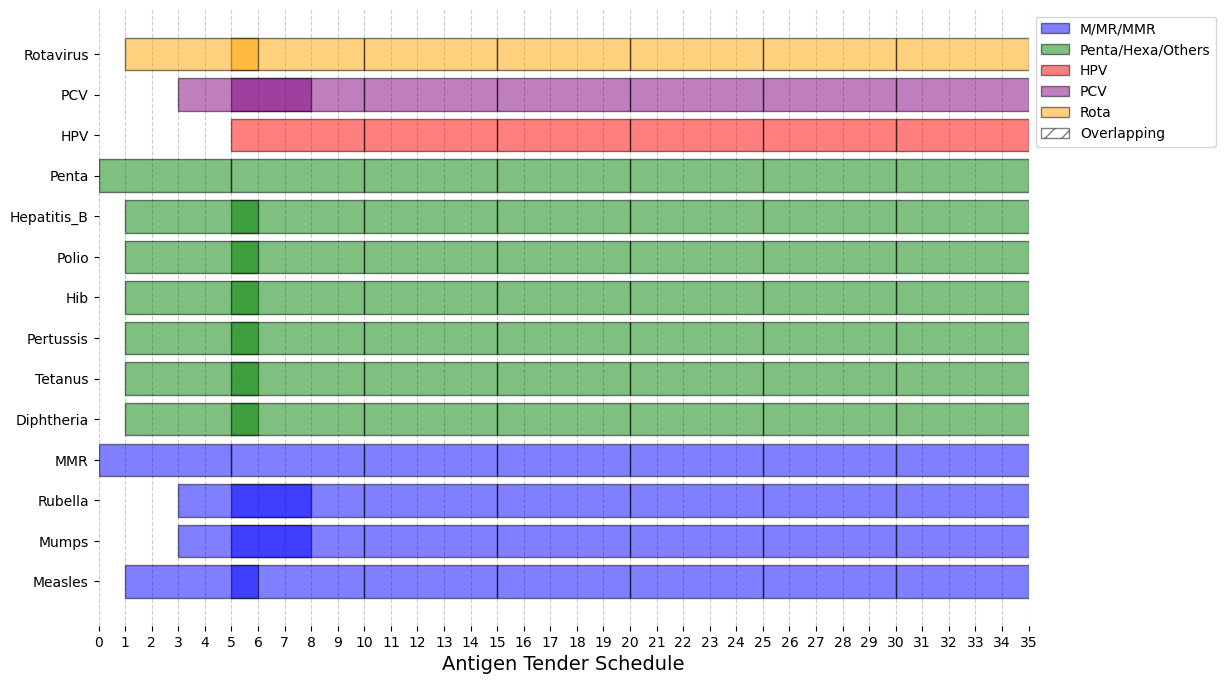

In [10]:
# fig, ax = plt.subplots(figsize=(10, 5))
fig, ax = plt.subplots(figsize=(12, 8))  # Adjust figure size


temp = {}
# Iterate through rows and plot bars based on conditions and color groups
for index, row in result_df.iterrows():
    if round(row["Value"]) == 1:
        start = row["Start"] - 1
        end = row["Finish"]

        # Choose color based on the group
        for group, tenders in color_groups.items():
            if row["Tender"] in tenders:
                x = row["Tender"]
                width = end - start
                left = start
                # print(row["Tender"], group)
                color = colors[group]
                # Adjust 'left' parameter for overlapping bars
                ax.barh(x, width=width, left=left, edgecolor="black", facecolor=color, alpha=0.5, zorder=10)
                # find the overlapping bars and have a hatch pattern
                temp[x] = {}
                temp[left] = {"start": left, "end": left + width, "width": width}


# ax.barh("Rotavirus", width=1, left=20, edgecolor=None, facecolor="orange", alpha=0.5, zorder=9, hatch="//")
# ax.barh("PCV", width=1, left=20, edgecolor=None, facecolor="purple", alpha=0.5, zorder=9, hatch="//")
# ax.barh("Hepatitis_B", width=1, left=20, edgecolor=None, facecolor="green", alpha=0.5, zorder=9, hatch="//")
# ax.barh("Polio", width=1, left=20, edgecolor=None, facecolor="green", alpha=0.5, zorder=9, hatch="//")
# ax.barh("Hib", width=1, left=15, edgecolor=None, facecolor="green", alpha=0.5, zorder=9, hatch="//")
# ax.barh("Pertussis", width=1, left=20, edgecolor=None, facecolor="green", alpha=0.5, zorder=9, hatch="//")
# ax.barh("Tetanus", width=1, left=20, edgecolor=None, facecolor="green", alpha=0.5, zorder=9, hatch="//")
# ax.barh("Diphtheria", width=1, left=20, edgecolor=None, facecolor="green", alpha=0.5, zorder=9, hatch="//")
# ax.barh("Rubella", width=1, left=15, edgecolor=None, facecolor="blue", alpha=0.5, zorder=9, hatch="//")
# ax.barh("Measles", width=1, left=15, edgecolor=None, facecolor="blue", alpha=0.5, zorder=9, hatch="//")
# ax.barh("Mumps", width=1, left=15, edgecolor=None, facecolor="blue", alpha=0.5, zorder=9, hatch="//")


# Set labels and show the plot
ax.set_xlim(0.5, 35)
ax.set_xticks(range(0, 36))

ax.set_xlabel("Antigen Tender Schedule", fontsize=14)
# ax.set_ylabel("Antigen")
# ax.set_title("Determistic Tender Schedule with Horizon - 10 Year")
ax.spines[["right", "top", "bottom", "left"]].set_visible(False)
ax.grid(True, which="both", axis="x", ls="--", c="0.8")

# Create a legend with adjusted location
legend_labels = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colors[group], alpha=0.5, edgecolor="black", label=group)
    for group in color_groups.keys()
] + [plt.Rectangle((0, 0), 1, 1, facecolor="white", alpha=0.5, edgecolor="black", hatch="//", label="Overlapping")]

ax.legend(
    handles=legend_labels,
    # labels=color_groups.keys(),
    loc="upper left",
    bbox_to_anchor=(1, 1),
    # ncols=5,
)

plt.savefig('Tender_Schedule_MMR_Penta.png', bbox_inches='tight', pad_inches=0.1, dpi=600)

In [16]:
legend_labels

In [20]:
temp

{'Measles': {},
 6: {'start': 6, 'end': 11, 'width': 5},
 20: {'start': 20, 'end': 25, 'width': 5},
 11: {'start': 11, 'end': 16, 'width': 5},
 30: {'start': 30, 'end': 35, 'width': 5},
 15: {'start': 15, 'end': 20, 'width': 5},
 25: {'start': 25, 'end': 30, 'width': 5},
 1: {'start': 1, 'end': 6, 'width': 5},
 'Mumps': {},
 'Rubella': {},
 'Diphtheria': {},
 16: {'start': 16, 'end': 21, 'width': 5},
 'Tetanus': {},
 'Pertussis': {},
 'Hib': {},
 'Polio': {},
 'Hepatitis_B': {},
 'HPV': {},
 5: {'start': 5, 'end': 10, 'width': 5},
 10: {'start': 10, 'end': 15, 'width': 5},
 'PCV': {},
 'Rotavirus': {}}

In [21]:
result_df["Value"].describe()

count    1152.000000
mean        0.072049
std         0.258681
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Value, dtype: float64